# Laboratório 01
## Disciplina Aprendizado de Máquina 2
## Professor: Kaique Almeida
### Human-In-The-Loop IoT dataset



Dataset: https://zenodo.org/records/17862334  
Kaggle: https://www.kaggle.com/datasets/abubakarwakili/hitl-iot-human-in-the-loop-iot-ids-dataset

#### Bibliotecas utilizadas

In [51]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
import seaborn as sns
from sklearn.metrics import confusion_matrix


#### Exploração Inicial

In [7]:
df = pd.read_csv('/content/HITL-IoT_dataset.csv')

In [8]:
print(df.shape)
print(df.columns)

(127845, 54)
Index(['timestamp', 'hour', 'day_of_week', 'is_weekend', 'src_ip', 'dst_ip',
       'src_mac', 'dst_mac', 'packet_size', 'ttl', 'is_internal_dst',
       'is_localhost', 'protocol', 'src_port', 'dst_port',
       'is_well_known_port', 'is_registered_port', 'is_dynamic_port',
       'device_name', 'device_type', 'device_thermostat', 'device_camera',
       'device_speaker', 'duration', 'bytes_sent', 'bytes_received',
       'bytes_ratio', 'bytes_per_second', 'packet_rate', 'is_business_hours',
       'is_night', 'protocol_tcp', 'protocol_udp', 'connection_frequency',
       'baseline_deviation', 'bytes_sent_mean_5', 'bytes_sent_std_5',
       'bytes_sent_mean_10', 'bytes_sent_std_10', 'bytes_sent_mean_20',
       'bytes_sent_std_20', 'connection_frequency_5',
       'connection_frequency_10', 'is_attack', 'attack_type', 'risk_score',
       'ml_confidence', 'ml_prediction', 'human_reviewed', 'human_decision',
       'human_confidence', 'decision_time', 'ml_human_agreement',

**Responda:**

Quantas dimensões tem o dataset principal ?

**Sua resposta:**  
Preencha

In [5]:
df.head()

,timestamp,hour,day_of_week,is_weekend,src_ip,dst_ip,src_mac,dst_mac,packet_size,ttl,...,attack_type,risk_score,ml_confidence,ml_prediction,human_reviewed,human_decision,human_confidence,decision_time,ml_human_agreement,annotator_id
0,2024-01-15T00:00:15,0,0,False,192.168.1.29,128.224.229.17,00:1A:2B:3C:4D:29,00:60:95:36:56:89,1259,163,...,normal,0.180730,0.227382,0,False,-1,0.0,0.0,False,NaN
1,2024-01-15T00:00:19,0,0,False,192.168.1.31,52.25.123.45,00:1A:2B:3C:4D:31,00:48:53:30:99:58,833,99,...,normal,0.041152,0.000000,0,False,-1,0.0,0.0,False,NaN
2,2024-01-15T00:00:23,0,0,False,192.168.1.25,35.186.224.25,00:1A:2B:3C:4D:25,FF:FF:FF:FF:FF:FF,385,203,...,device_hijacking,0.858343,0.961525,1,False,-1,0.0,0.0,False,NaN
3,2024-01-15T00:00:28,0,0,False,192.168.1.21,185.220.100.240,00:1A:2B:3C:4D:21,FF:FF:FF:FF:FF:FF,895,176,...,port_scanning,0.688383,0.823752,1,False,-1,0.0,0.0,False,NaN
4,2024-01-15T00:00:29,0,0,False,192.168.1.29,104.16.132.229,00:1A:2B:3C:4D:29,00:33:74:33:30:10,1038,195,...,normal,0.006707,0.000000,0,False,-1,0.0,0.0,False,NaN


In [6]:
y = df['is_attack'] # Target

#### Variáveis relacionadas a tempo:

    timestamp, hour, day_of_week, is_weekend, is_business_hours, is_night

#### Variáveis de rede

    src_ip, dst_ip, src_mac, dst_mac
    src_port, dst_port
    protocol, protocol_tcp, protocol_udp
    ttl, packet_size

#### Variáveis de Tráfego

    duration, bytes_sent, bytes_received,
    bytes_ratio, bytes_per_second, packet_rate

#### Comportamento temporal

    connection_frequency, baseline_deviation

    bytes_sent_mean_5, bytes_sent_std_5
    bytes_sent_mean_10, bytes_sent_std_10
    bytes_sent_mean_20, bytes_sent_std_20

    connection_frequency_5, connection_frequency_10

#### Tipo de dispositivo

    device_name, device_type, device_thermostat,
    device_camera, device_speaker

#### HILT

    is_attack, attack_type, risk_score,
    ml_prediction, ml_confidence,

    human_reviewed, human_decision,
    human_confidence

    ml_human_agreement, annotator_id, decision_time







In [10]:
# Features que vazam informação
leakage_cols = [
    'is_attack',          # target
    'attack_type',        # versão mais detalhada do target
    'ml_prediction',      # previsão de outro modelo (!)
    'ml_confidence',      # confiança do modelo
    'risk_score',         # derivado do target
    'human_decision',     # rótulo humano
    'human_confidence',
    'ml_human_agreement',
    'human_reviewed',
    'decision_time'
]

# Features de identificação
id_cols = [
    'timestamp',
    'src_ip', 'dst_ip',
    'src_mac', 'dst_mac',
    'device_name',
    'annotator_id'
]

cols_drop = leakage_cols + id_cols



df_model = df.copy()
df_model = df_model.drop(columns=[c for c in cols_drop if c in df.columns])

df_model = pd.get_dummies(df_model, drop_first=True) # Tratamento para variáveis categóricas

df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna()
print(df_model.shape)

(127845, 40)


**Pergunta:**  
Por que excluir as colunas listadas em leakage_cols faz sentido, pensando em criar um classificador ?

**Resposta:**  
Preencha

In [12]:
df_model.describe()

,hour,day_of_week,packet_size,ttl,src_port,dst_port,duration,bytes_sent,bytes_received,bytes_ratio,...,connection_frequency,baseline_deviation,bytes_sent_mean_5,bytes_sent_std_5,bytes_sent_mean_10,bytes_sent_std_10,bytes_sent_mean_20,bytes_sent_std_20,connection_frequency_5,connection_frequency_10
count,127845.000000,127845.000000,127845.000000,127845.000000,127845.000000,127845.000000,127845.000000,1.278450e+05,1.278450e+05,127845.000000,...,127845.000000,127845.000000,1.278450e+05,1.278450e+05,1.278450e+05,1.278450e+05,1.278450e+05,1.278450e+05,127845.000000,127845.000000
mean,11.464359,2.993774,782.615949,143.268184,57329.530955,3115.547796,8.968932,8.104447e+04,9.169258e+04,0.987610,...,5.501310,-0.001788,8.105710e+04,5.991127e+04,8.106234e+04,6.620224e+04,8.106662e+04,7.161055e+04,27.504392,55.002613
std,6.923718,1.998042,415.341285,64.708136,4730.622914,6401.173689,11.357400,2.007590e+05,2.182071e+05,0.460591,...,2.874884,1.154137,1.441443e+05,1.443709e+05,1.355700e+05,1.414585e+05,1.310307e+05,1.387956e+05,6.426457,9.067497
min,0.000000,0.000000,64.000000,32.000000,49152.000000,80.000000,0.500287,5.000000e+01,2.200000e+01,0.500000,...,1.000000,-1.999998,1.966000e+02,0.000000e+00,4.490000e+02,0.000000e+00,4.967000e+02,0.000000e+00,1.000000,1.000000
25%,5.000000,1.000000,423.000000,87.000000,53225.000000,80.000000,3.224665,1.795000e+03,2.064000e+03,0.641743,...,3.000000,-1.002384,2.511800e+03,1.454833e+03,2.684200e+03,1.601572e+03,2.823500e+03,1.984113e+03,23.000000,49.000000
50%,11.000000,3.000000,783.000000,143.000000,57324.000000,443.000000,5.939210,6.042000e+03,6.973000e+03,0.843320,...,6.000000,-0.002496,6.242600e+03,4.070509e+03,6.415600e+03,4.795049e+03,6.443950e+03,5.542952e+03,28.000000,55.000000
75%,17.000000,5.000000,1142.000000,199.000000,61418.000000,7001.000000,8.649492,6.991900e+04,7.735200e+04,1.210836,...,8.000000,0.998595,7.555500e+04,5.134379e+04,7.445130e+04,6.740423e+04,7.315160e+04,6.570196e+04,32.000000,61.000000
max,23.000000,6.000000,1500.000000,255.000000,65535.000000,65532.000000,59.993744,4.999840e+06,6.955225e+06,3.354167,...,10.000000,1.999942,1.521847e+06,2.167739e+06,1.381972e+06,1.572803e+06,1.381972e+06,1.300495e+06,49.000000,94.000000


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

## PCA

In [14]:
pca = PCA()
pca.fit(X_scaled)

var_acumulada = np.cumsum(pca.explained_variance_ratio_)
print(var_acumulada)

[0.20781431 0.32375594 0.38497905 0.43760579 0.4882912  0.53705866
 0.58461326 0.63145506 0.67212656 0.70480162 0.73397476 0.76048521
 0.78677666 0.81293089 0.83865464 0.86112487 0.88308195 0.90347224
 0.9225551  0.93742001 0.9500678  0.95988404 0.96810459 0.97542378
 0.98197988 0.9876745  0.99321807 0.99642697 0.99818645 0.99943068
 0.99982992 1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]


**Pergunta:**  
Qual a variância explicada pelo primeiro componente PC1 ?

**Resposta:**  
Preencha

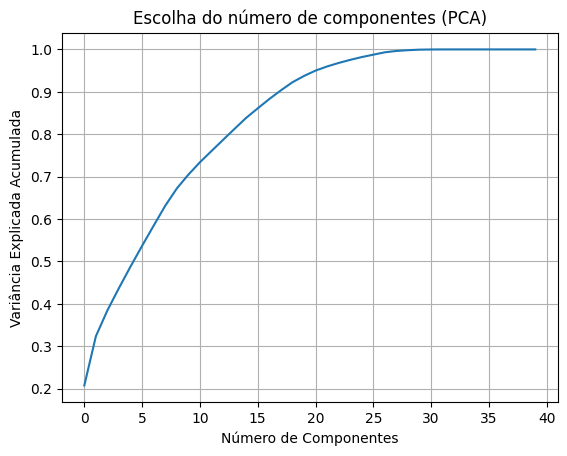

In [15]:
plt.figure()
plt.plot(var_acumulada)
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Escolha do número de componentes (PCA)')
plt.grid()
plt.show()

In [16]:
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)


## t-SNE

In [17]:
%%time
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=200,
    n_iter=1500,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca[:10000]) # Feito slice para otimizar o tempo

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


CPU times: user 3min 8s, sys: 255 ms, total: 3min 8s
Wall time: 3min 14s


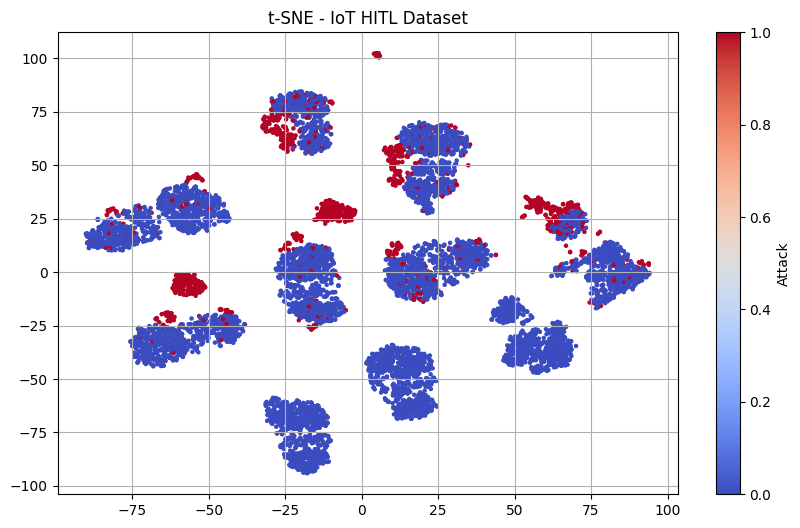

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y[:10000],
    cmap='coolwarm',
    s=5
)

plt.title("t-SNE - IoT HITL Dataset")
plt.colorbar(label='Attack')
plt.grid(True)

plt.show()

**Pergunta**  
Quais insights essa visualização traz?  
Analisando o dataset, o que os clusters azuis representam?

**Resposta:**  
Preencha

## Testando Classificadores

### Tratando desbalanceamento

In [19]:
y.value_counts(normalize=True)

,proportion
is_attack,
False,0.849998
True,0.150002


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y, #Garante que y_train e y_test tennham a mesma proporção de y
    random_state=42
)

In [21]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    stratify=y, #Garante que y_train e y_test tennham a mesma proporção de y
    random_state=42
)

In [22]:
y_train.value_counts(normalize=True)

,proportion
is_attack,
False,0.849994
True,0.150006


### KNN

In [23]:
%%time
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("KNN")
print(classification_report(y_test, y_pred))

KNN
              precision    recall  f1-score   support

       False       0.96      1.00      0.98     21734
        True       1.00      0.77      0.87      3835

    accuracy                           0.97     25569
   macro avg       0.98      0.88      0.92     25569
weighted avg       0.97      0.97      0.96     25569

CPU times: user 21.8 s, sys: 13.2 ms, total: 21.8 s
Wall time: 21.9 s


### KNN + PCA

In [24]:
%%time
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train_pca)

y_pred = knn.predict(X_test_pca)
print("KNN")
print(classification_report(y_test_pca, y_pred))

KNN
              precision    recall  f1-score   support

       False       0.96      1.00      0.98     21734
        True       1.00      0.76      0.86      3835

    accuracy                           0.96     25569
   macro avg       0.98      0.88      0.92     25569
weighted avg       0.97      0.96      0.96     25569

CPU times: user 19.4 s, sys: 13 ms, total: 19.4 s
Wall time: 19.6 s


**Pergunta:**  
O que o valor recall 0.77 para True representa?  
Em um modelo KNN, a complexidade do modelo cresce em função de que?  
No modelo KNN + PCA, quando o modelo diz que determinada amostra não é ataque, qual é a confiabilidade da previsão?


**Resposta:**  
Preencha

### Regressão Logística

In [26]:
%%time
lr = LogisticRegression(class_weight='balanced', max_iter=1000) #class_weight penaliza classes raras
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Logistic Regression")
print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

       False       0.99      0.97      0.98     21734
        True       0.84      0.92      0.87      3835

    accuracy                           0.96     25569
   macro avg       0.91      0.94      0.93     25569
weighted avg       0.96      0.96      0.96     25569

CPU times: user 2.64 s, sys: 2.99 ms, total: 2.64 s
Wall time: 1.37 s


In [27]:
coef = lr.coef_[0]

features = df_model.columns  # ou use uma das opções acima

df_importance = pd.DataFrame({
    'feature': features,
    'coef': coef,
    'abs_coef': abs(coef)
}).sort_values(by='abs_coef', ascending=False)

print(df_importance.head(20))

                 feature      coef  abs_coef
15              duration  4.438849  4.438849
16            bytes_sent  2.316369  2.316369
24          protocol_udp -1.350816  1.350816
35          protocol_UDP -1.350816  1.350816
23          protocol_tcp  1.350816  1.350816
13         device_camera -0.856273  0.856273
29    bytes_sent_mean_10 -0.764896  0.764896
31    bytes_sent_mean_20  0.759468  0.759468
18           bytes_ratio  0.728449  0.728449
36  device_type_doorbell  0.713541  0.713541
8               dst_port  0.597755  0.597755
20           packet_rate  0.545367  0.545367
27     bytes_sent_mean_5 -0.471168  0.471168
11       is_dynamic_port  0.430183  0.430183
9     is_well_known_port -0.414136  0.414136
28      bytes_sent_std_5  0.397180  0.397180
10    is_registered_port  0.359952  0.359952
17        bytes_received -0.339826  0.339826
30     bytes_sent_std_10  0.315948  0.315948
37   device_type_speaker  0.313696  0.313696


### Regressão Logística + PCA

In [28]:
%%time
lr = LogisticRegression(class_weight='balanced', max_iter=1000) #class_weight penaliza classes raras
lr.fit(X_train_pca, y_train_pca)

y_pred = lr.predict(X_test_pca)
print("Logistic Regression")
print(classification_report(y_test_pca, y_pred))

Logistic Regression
              precision    recall  f1-score   support

       False       0.98      0.96      0.97     21734
        True       0.82      0.91      0.86      3835

    accuracy                           0.96     25569
   macro avg       0.90      0.94      0.92     25569
weighted avg       0.96      0.96      0.96     25569

CPU times: user 1.72 s, sys: 14 µs, total: 1.72 s
Wall time: 911 ms


**Pergunta**
Analisando a Regressão Logística + PCA, qual a sensibilidade na detecção de ataques do modelo?

### Decision Tree

In [38]:
%%time
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Decision Tree")
print(classification_report(y_test, y_pred))

Decision Tree
              precision    recall  f1-score   support

       False       0.99      1.00      1.00     21734
        True       1.00      0.96      0.98      3835

    accuracy                           0.99     25569
   macro avg       1.00      0.98      0.99     25569
weighted avg       0.99      0.99      0.99     25569

CPU times: user 4.11 s, sys: 2.89 ms, total: 4.11 s
Wall time: 5.35 s


In [39]:
importances = dt.feature_importances_

features = df_model.columns  # ou lista equivalente

df_importance = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)
df_importance['importance'] = df_importance['importance'].round(2)

print(df_importance.head(20))

                   feature  importance
15                duration        0.77
8                 dst_port        0.12
18             bytes_ratio        0.03
16              bytes_sent        0.03
9       is_well_known_port        0.01
37     device_type_speaker        0.01
36    device_type_doorbell        0.01
12       device_thermostat        0.01
24            protocol_udp        0.00
30       bytes_sent_std_10        0.00
32       bytes_sent_std_20        0.00
29      bytes_sent_mean_10        0.00
4                      ttl        0.00
3              packet_size        0.00
38  device_type_thermostat        0.00
0                     hour        0.00
1              day_of_week        0.00
19        bytes_per_second        0.00
5          is_internal_dst        0.00
2               is_weekend        0.00


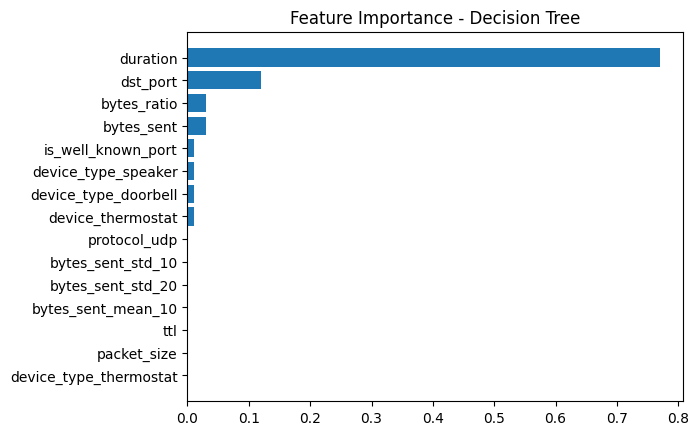

In [34]:
top_n = 15
top = df_importance.head(top_n)

plt.figure()
plt.barh(top['feature'], top['importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance - Decision Tree')
plt.show()

### Decision Tree + PCA

In [44]:
%%time
dt_pca = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_pca.fit(X_train_pca, y_train_pca)

y_pred = dt_pca.predict(X_test_pca)
print("Decision Tree")
print(classification_report(y_test_pca, y_pred))

Decision Tree
              precision    recall  f1-score   support

       False       0.98      0.98      0.98     21734
        True       0.91      0.91      0.91      3835

    accuracy                           0.97     25569
   macro avg       0.95      0.94      0.95     25569
weighted avg       0.97      0.97      0.97     25569

CPU times: user 9.63 s, sys: 19.5 ms, total: 9.65 s
Wall time: 11.4 s


**Pergunta**  

Como fica a explicabilidade do Decision Tree, uma vez que foi aplicado o PCA ás features?

Na aplicação do decision tree qual feature é a mais provável a estar na raiz da árvore?

**Resposta:**  
Preencha

tree_rules = export_text(dt, feature_names=list(df_model.columns))  

print(tree_rules[:2000])  # limita pra não explodir o terminal

### Random Forest


In [45]:
%%time
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Random Forest")
print(classification_report(y_test, y_pred))

Random Forest
              precision    recall  f1-score   support

       False       0.99      1.00      1.00     21734
        True       1.00      0.97      0.98      3835

    accuracy                           1.00     25569
   macro avg       1.00      0.98      0.99     25569
weighted avg       1.00      1.00      1.00     25569

CPU times: user 50 s, sys: 41.2 ms, total: 50 s
Wall time: 51.2 s


### Random Forest + PCA

In [46]:
%%time
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_pca, y_train_pca)

y_pred = rf.predict(X_test_pca)
print("Random Forest")
print(classification_report(y_test_pca, y_pred))

Random Forest
              precision    recall  f1-score   support

       False       0.98      1.00      0.99     21734
        True       1.00      0.90      0.95      3835

    accuracy                           0.99     25569
   macro avg       0.99      0.95      0.97     25569
weighted avg       0.99      0.99      0.98     25569

CPU times: user 1min 44s, sys: 60.2 ms, total: 1min 44s
Wall time: 1min 45s


### XGBoost

In [47]:
%%time
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print("XGBoost")
print(classification_report(y_test, y_pred))

XGBoost
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     21734
        True       1.00      0.98      0.99      3835

    accuracy                           1.00     25569
   macro avg       1.00      0.99      0.99     25569
weighted avg       1.00      1.00      1.00     25569

CPU times: user 3.52 s, sys: 12 ms, total: 3.54 s
Wall time: 1.93 s


In [48]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.9959716844616527


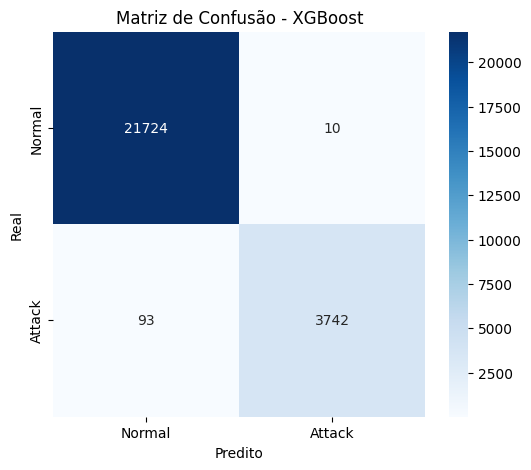

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost')

plt.show()

**Pergunta**  

No classificador com XGBoost, quantos ataques foram classificados como normal?

**Resposta:**  
Preencha

###XGBoost + PCA

In [78]:
%%time
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb.fit(X_train_pca, y_train_pca)

y_pred = xgb.predict(X_test_pca)
print("XGBoost")
print(classification_report(y_test_pca, y_pred))

XGBoost
              precision    recall  f1-score   support

       False       0.99      0.99      0.99     21734
        True       0.96      0.93      0.94      3835

    accuracy                           0.98     25569
   macro avg       0.97      0.96      0.97     25569
weighted avg       0.98      0.98      0.98     25569

CPU times: user 5.04 s, sys: 17.5 ms, total: 5.05 s
Wall time: 4.86 s


### Naive Bayes

In [53]:
%%time
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
print("Naive Bayes")
print(classification_report(y_test, y_pred))

Naive Bayes
              precision    recall  f1-score   support

       False       1.00      0.33      0.50     21734
        True       0.21      0.99      0.34      3835

    accuracy                           0.43     25569
   macro avg       0.60      0.66      0.42     25569
weighted avg       0.88      0.43      0.48     25569

CPU times: user 131 ms, sys: 1 ms, total: 132 ms
Wall time: 132 ms


### Naive Bayes + PCA

In [54]:
%%time
nb = GaussianNB()
nb.fit(X_train_pca, y_train_pca)

y_pred = nb.predict(X_test_pca)
print("Naive Bayes")
print(classification_report(y_test_pca, y_pred))

Naive Bayes
              precision    recall  f1-score   support

       False       0.92      0.98      0.95     21734
        True       0.83      0.54      0.66      3835

    accuracy                           0.91     25569
   macro avg       0.88      0.76      0.80     25569
weighted avg       0.91      0.91      0.91     25569

CPU times: user 102 ms, sys: 998 µs, total: 103 ms
Wall time: 102 ms


**Pergunta**  

Explique a diferença de desempenho entre o Naive Bayes sem PCA e com PCA?

**Resposta:**  
Preencha

**Pergunta**  

Discorra sobre o tempo de treinamento dos modelos paramétricos x não paramétricos.

**Resposta:**  
Preencha